Librerías y Funciones propias:

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.adapt import adapt
from helpers.room import room
from helpers.generateRirs import generateRirs
from helpers.perturbSecondaryPath import perturbSecondaryPath

Simulation:

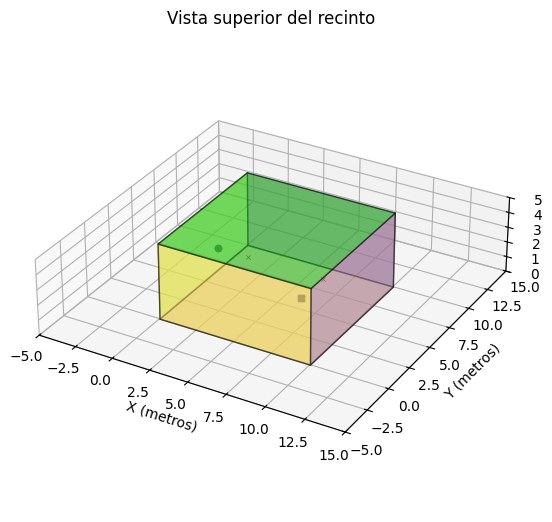

In [3]:
fs = 48000
room = room(fs)

Obtain RIRs:

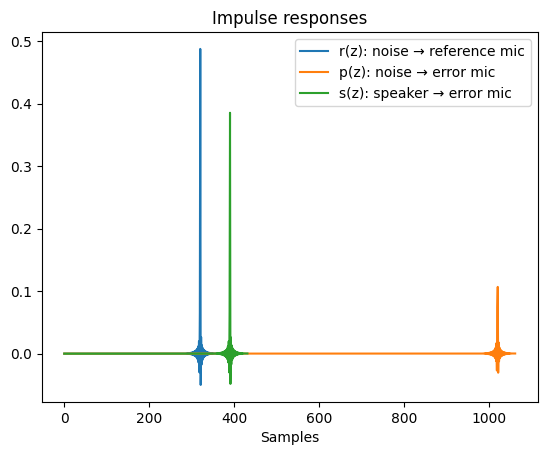

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
Reference path length:  362
Primary path length:  1062
Secondary path length:  432


In [4]:
rir_r, rir_p, rir_s = generateRirs(fs, room)

The SPM algorithm:

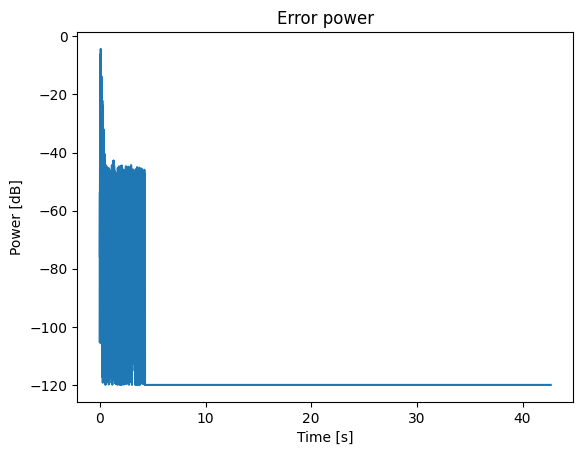

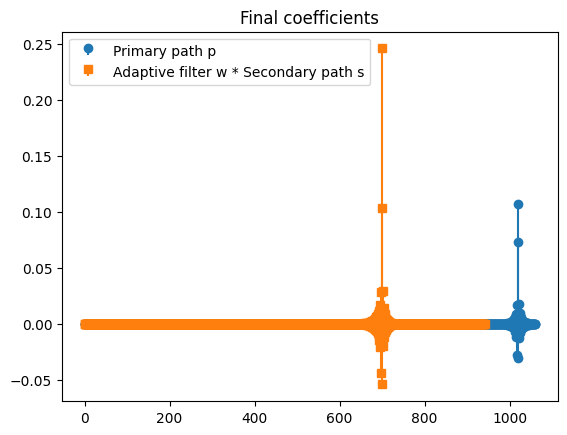

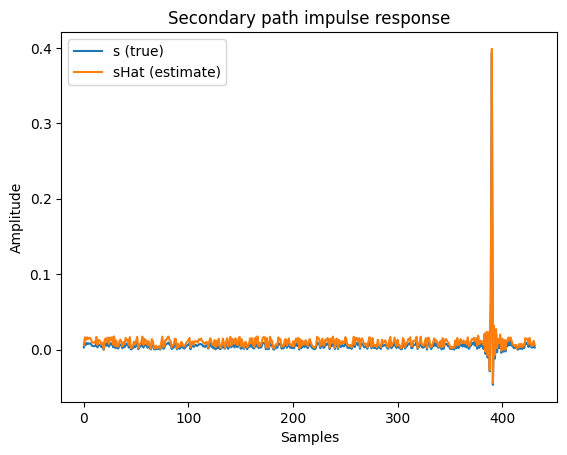

Difference between mean squared value of S(z) and model:  2.3067554068931528e-05


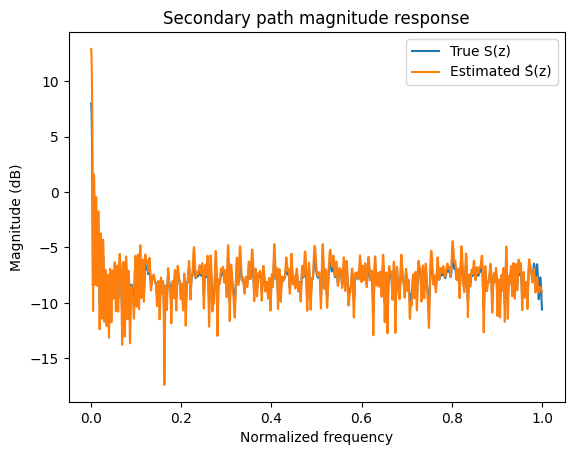

In [22]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 500
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
muw = 25
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []
wSpectrum = np.fft.rfft(w, N_w)

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = s.copy()
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []
mus = 0.03

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)

# Mode switching
ANC = True
SPM = False
counter = 0

# Initialization for T21 criterion
errorHistory = np.zeros(nBlocks)
T21Counter = 0
smoothedError = 0

for k in range(nBlocks):
    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)

    # Adaptive filter W(z)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)

    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)

    # Error signal
    e = pBlockOutput - fyBlockOutput

    # Filter y(n) by the plant model
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)

    # Define if switching to SPM is necessary based on T12 criterion
    if ANC:
        Px = np.mean(xBlock**2)
        Pe = np.mean(e**2)

        T12 = 10*np.log10(Px/Pe)

        if T12 < 10:
            print("T12 detected divergence in block: ", k, ", switching to SPM")
            kSwitch = k
            SPM = True
            ANC = False

            # Reset buffers
            wBuffer = np.zeros(M_w - 1)
            wHatBuffer = np.zeros(M_w - 1)
            pBuffer = np.zeros(M_p - 1)
            sBuffer = np.zeros(M_s - 1)
            sHatBuffer = np.zeros(M_sHat - 1)
            sHatPrimeBuffer = np.zeros(M_sHat - 1)
            rBuffer = np.zeros(M_r - 1)
            continue

    ###################### if ANC is on ###########################
    if ANC:
        dHat = e + yPrimeBlockOutput
        eHat = dHat - yHatBlockOutput

        # Adapt filter
        w = adapt(fxBlockOutput, eHat, M_w, blocklength, w, muw)

        # Recalculate filter spectrum
        wSpectrum = np.fft.rfft(w, N_w)

        if k == 50:
            break

    # Error history
    e_hist[k * blocklength:(k+1) * blocklength] = e

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

s = s + 0.01 * np.random.rand(len(s))
sSpectrum = np.fft.rfft(s, N_s)


# Reset buffers
wBuffer = np.zeros(M_w - 1)
wHatBuffer = np.zeros(M_w - 1)
pBuffer = np.zeros(M_p - 1)
sBuffer = np.zeros(M_s - 1)
sHatBuffer = np.zeros(M_sHat - 1)
sHatPrimeBuffer = np.zeros(M_sHat - 1)
rBuffer = np.zeros(M_r - 1)

# hasta aca tenemos un w que funciona para s viejo

for k in range(nBlocks):
    if k < 50:
        continue

    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)

    # Adaptive filter W(z)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    
    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)

    # Error signal
    e = pBlockOutput - fyBlockOutput

    # Filter y(n) by the plant model
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)

    dHat = e - yPrimeBlockOutput

    eHat = dHat + yHatBlockOutput

    # Adapt secondary path model (helper function utilizes inverse gradient)
    yBlockOutputPadded = np.concatenate([yBlockOutput, np.zeros(M_sHat - 1)])
    eHatPadded = np.concatenate([eHat, np.zeros(M_sHat - 1)])
    crossCorrelationResult = np.fft.irfft(np.fft.rfft(yBlockOutputPadded, N_sHat).conj() * np.fft.rfft(eHatPadded, N_sHat), N_sHat)
    crossCorrelationResult[M_sHat:] = 0
    crossCorrelationResult = crossCorrelationResult[:M_sHat]
    crossCorrelationResult /= blocklength
    sHat =  sHat - mus * crossCorrelationResult

    # Recalculate sHat spectrum
    sHatSpectrum = np.fft.rfft(sHat, N_sHat)

plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

print("Difference between mean squared value of S(z) and model: ", np.mean((s - sHat)**2))

freqs = np.linspace(0,1,len(sHatSpectrum))

plt.figure()
plt.plot(freqs, 20*np.log10(np.abs(sSpectrum)+1e-12), label="True S(z)")
plt.plot(freqs, 20*np.log10(np.abs(sHatSpectrum)+1e-12), label="Estimated Ŝ(z)")
plt.title("Secondary path magnitude response")
plt.xlabel("Normalized frequency")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.show()


The full implementation:

T12 detected divergence in block:  100
T12 value:  26.31910058336046
Switching to SPM
T21 detected convergence in block:  146
Difference between mean squared value of S(z) and model:  4.809405969769691e-07
Switching to ANC...
Final Difference between mean squared value of S(z) and model:  4.809405969769691e-07


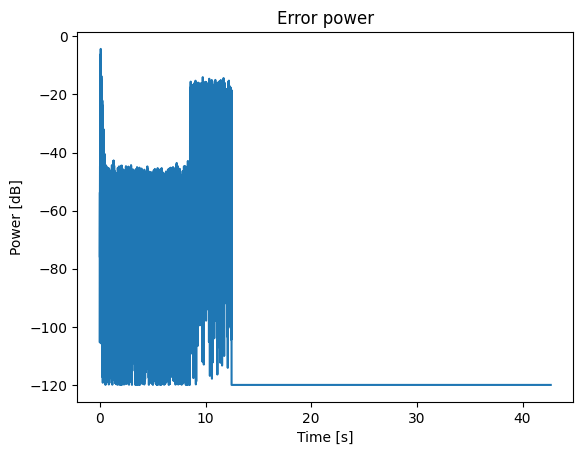

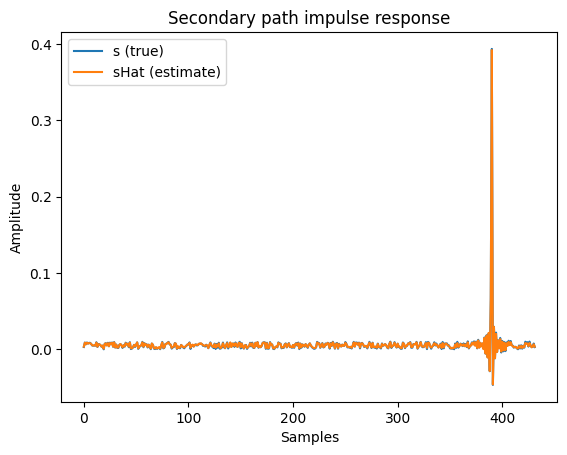

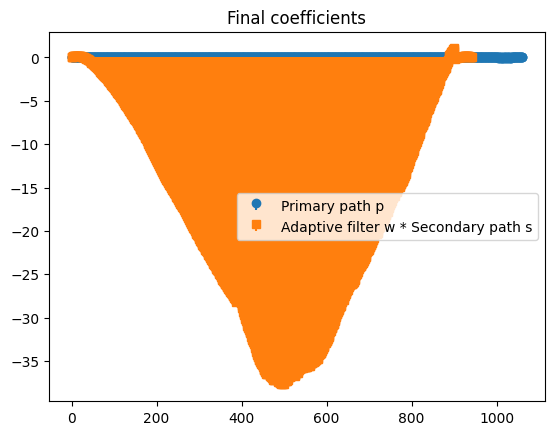

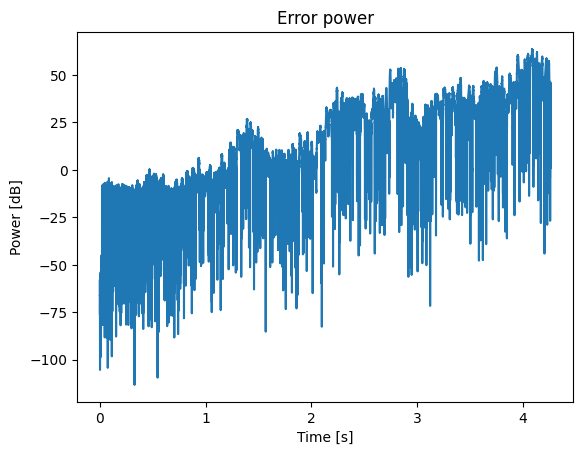

In [ ]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 500
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
muw = 25
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []
wSpectrum = np.fft.rfft(w, N_w)

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = s.copy()
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []
mus = 0.15

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)

# Mode switching
ANC = True
SPM = False

# Initialization for T12 and T21 criterions
errorHistory = np.zeros(nBlocks)
T21Counter = 0
smoothedError = 0
kSwitch = 0

for k in range(nBlocks):
    # Perturb secondary path
    if k == 100:
        s = s + 0.01 * np.random.rand(len(s))
        sSpectrum = np.fft.rfft(s, N_s)
        # ANC = False
        # SPM = True
        # kSwitch = k

    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)

    # Adaptive filter W(z)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)

    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)

    # Error signal
    e = pBlockOutput - fyBlockOutput

    # Filter y(n) by the plant model
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)

    # Define if switching to SPM is necessary based on T12 criterion
    if ANC and k > 5:
        Px = np.mean(xBlock**2)
        Pe = np.mean(e**2)

        T12 = 10*np.log10(Px/Pe)

        if T12 < 30 and k > (kSwitch + 5):
            print("T12 detected divergence in block: ", k)
            print("T12 value: ", T12)
            print("Switching to SPM")
            kSwitch = k
            SPM = True
            ANC = False

            # Reset buffers
            wBuffer = np.zeros(M_w - 1)
            wHatBuffer = np.zeros(M_w - 1)
            pBuffer = np.zeros(M_p - 1)
            sBuffer = np.zeros(M_s - 1)
            sHatBuffer = np.zeros(M_sHat - 1)
            sHatPrimeBuffer = np.zeros(M_sHat - 1)
            rBuffer = np.zeros(M_r - 1)

            # Log error before reseting
            e_hist[k * blocklength:(k+1) * blocklength] = e
            continue

    ###################### if ANC is on ###########################
    if ANC:
        dHat = e + yPrimeBlockOutput
        eHat = dHat - yHatBlockOutput

        # Adapt filter
        w = adapt(fxBlockOutput, eHat, M_w, blocklength, w, muw)

        # Recalculate filter spectrum
        wSpectrum = np.fft.rfft(w, N_w)

    ###################### if SPM is on ###########################
    elif SPM:     
        dHat = e - yPrimeBlockOutput
        eHat = dHat + yHatBlockOutput

        # Adapt secondary path model (helper function "adapt" utilizes inverse gradient)
        yBlockOutputPadded = np.concatenate([yBlockOutput, np.zeros(M_sHat - 1)])
        eHatPadded = np.concatenate([eHat, np.zeros(M_sHat - 1)])
        crossCorrelationResult = np.fft.irfft(np.fft.rfft(yBlockOutputPadded, N_sHat).conj() * np.fft.rfft(eHatPadded, N_sHat), N_sHat)
        crossCorrelationResult[M_sHat:] = 0
        crossCorrelationResult = crossCorrelationResult[:M_sHat]
        crossCorrelationResult /= blocklength
        sHat =  sHat - mus * crossCorrelationResult

        # Recalculate sHat spectrum
        sHatSpectrum = np.fft.rfft(sHat, N_sHat)

        # Define if switching to ANC is necessary based on T21 criterion
        blockErrorPower = np.mean(eHat**2)

        if smoothedError == 0:
            smoothedError = blockErrorPower
        else:
            smoothedError = 0.99 * smoothedError + (1 - 0.99) * blockErrorPower

        errorHistory[k] = smoothedError

        if k > kSwitch + 2*20:

            mean_recent = np.mean(errorHistory[k-20:k])
            mean_past   = np.mean(errorHistory[k-2*20:k-20])

            T21 = (mean_recent - mean_past) / mean_past

            if T21 > -0.0001:
                T21Counter += 1
                if T21Counter > 5:
                    print("T21 detected convergence in block: ", k)
                    print("Difference between mean squared value of S(z) and model: ", np.mean((s - sHat)**2))
                    print("Switching to ANC...")
                    kSwitch = k
                    ANC = True
                    SPM = False

                    # Reset buffers
                    wBuffer = np.zeros(M_w - 1)
                    wHatBuffer = np.zeros(M_w - 1)
                    pBuffer = np.zeros(M_p - 1)
                    sBuffer = np.zeros(M_s - 1)
                    sHatBuffer = np.zeros(M_sHat - 1)
                    sHatPrimeBuffer = np.zeros(M_sHat - 1)
                    rBuffer = np.zeros(M_r - 1)

                    break
            else:
                T21Counter = 0

    # Error history
    e_hist[k * blocklength:(k+1) * blocklength] = e

print("Final Difference between mean squared value of S(z) and model: ", np.mean((s - sHat)**2))

# plt.figure()
# plt.plot(s, label='s (true)')
# plt.plot(sHat, label='sHat (estimate)')
# plt.legend()
# plt.title('Secondary path impulse response')
# plt.xlabel('Samples')
# plt.ylabel('Amplitude')
# plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 50
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
mu = 2
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)
mean_e_p_hist = np.zeros(nBlocks)
w_hist = np.zeros((N, M_w))

plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

for k in range(nBlocks):

    # if k < 100:
    #     continue

    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)
    rOutputBlocks.append(rBlockOutput)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Adaptive filter W(z)
    wSpectrum = np.fft.rfft(w, N_w)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    wOutputBlocks.append(yBlockOutput)
    
    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fyBlockOutput)

    e = pBlockOutput - fyBlockOutput

    # Reconstruct desired signal 
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)
    sHatPrimeOutputBlocks.append(yPrimeBlockOutput)

    dHat = e + yPrimeBlockOutput

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)
    sHatOutputBlocks.append(fxBlockOutput)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)
    wHatOutputBlocks.append(yHatBlockOutput)

    eHat = dHat - yHatBlockOutput

    # LMS algorithm
    w = adapt(fxBlockOutput, eHat, M_w, blocklength, w, mu)

    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e
    w_hist[k * blocklength:(k+1) * blocklength, :] = w

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
for k in range(M_w):
    plt.plot(t, w_hist[:, k])
plt.title('Coefficient convergence')
plt.xlabel('Time [s]')
plt.ylabel('Value')
plt.show()


